# Group Project 1 "Runoff Prediction" Exercise Sheet

Group N: Jane Doe, John Doe, James Doe **<- Enter your group number / name here**

Welcome to the lovely home of your group project for this years' *Introduction to Advanced Data Analytics* Lecture. This is the place where you find all information regarding your group project, and also the place to work on your group project. You will submit a copy of this file in the end.

## Project description

You are working in groups of max. 3 people. Each group will get assigned, at random, a dataset and a method that was discussed during the lecture. The datasets are coming from the Earth System Sciences, and are both taken from real-world research problems. Your task is to use the two methods you were assigned (one linear and one nonlinear statistical learning method) to fit and predict from the dataset you have been given. For the prediction, you will be given a part of the dataset consisting only of predictors but with target values omitted. For comparing your methods, you will also fit a multiple linear regression model (without any regularisation) to the dataset.

The methods you have been assigned may or may not be suitable one for the dataset. However, the final performance of your code, that is the precision of your prediction, is not important. The key goal is to show that 

1. you understand the theoretical background of what a specific method is doing or attempts to do;
2. you are aware of the strengths and limitations of a given method applied to a concrete atmospheric science problem;
3. you are able to correctly apply the method in a training/testing context (e.g., cross-validation, hyperparameter selection, etc.);
4. you are able to interpret the results of your method application to the atmospheric science problem.

Below we have already constructed a framework that helps you through data reading and preparation, gives you space for model fitting and prediction and in the end asks you the questions you need to work on. So you just need to work along the framework and make sure you carefully answer each question, and then you can hand in!

## Method and Data

The pool of methods consists of

| Method | R packages | Function/Help |
| :- | :- | :- |
| Backward subset selection | `leaps` | `?regsubsets` |
| Principal component regression | `pls` | `?pcr` |
| Ridge Regression | `glmnet` | `?glmnet` |
| Lasso Regression | `glmnet` | `?glmnet` |
| Multivariate adaptive regression splines | `earth` | `?earth` |
| Random Forest | `randomForest` | `?randomForest` |
| Boosted Trees | `gbm` | `?gbm` |

NB: 
- You will be working with one linear and one non-parametric method from the method pool above. Please find on Moodle which of the methods is assigned to you.
- You can follow the coding style from the exercises to implement your method. Use the help function (e.g. `?regsubsets`) to familiarize yourself with your methods and how to implement them.
- In some cases, you will have to reduce the number of predictors to make it work with resource-demanding methods. 


And this is the dataset you'll be working with:

1. **Predicting runoff accross Europe** <br>
This data set contains information on runoff, precipitation and temperature from a long pre-industrial control run of the CESM model. For the purpose of this project, the simulated data is restricted to cover Europe and a randomly selected 30 year time block. The following two versions of the data are available:  <br>

    a. To mimic station data, 15 grid cells were selected at random. At these location data on runoff, precipitation and temperature are available.  <br>
    b. The full gridded data set is only available for precipitation and temperature.  <br>

    The goal of projects working with this data set is to develop a statistical model for runoff using the station data. Following Gudmundsson & Seneviratne (2015)$^1$, runoff $Q_{(s,t)}$ at spatial location $s$ and time step $t$ can be modelled as a function of precipitation, $P_{(s,t)}$ , and temperature $T_{(s,t)}$, such that 
    
    $Q_{(s,t)}=f(\tau_\lambda (P_{(s,t)} ), \tau_\lambda (T_{(s,t)} ))$. 
    
    The embedding operator $\tau_\lambda (X_{(s,t)} )=[X_{(s,t)},X_{(s,t-1)},…,X_{(s,t-λ)}]$ gives access to the past $\lambda$ time steps. You will train such a model using the station data. The trained model will then be used to infer runoff across the entire spatial domain using gridded precipitation and temperature as predictors.
    
    For a successful application, you will need to find the right parameters for the machine learning model $f$ (the exact method is specified for each project) as well as a good value for the embedding parameter $\lambda$. Select and argue for an approach that helps you to ensure that the chosen model parameters do not over-fit the training data. 
    
    $^1$ Gudmundsson, L. and S. I. Seneviratne (2015). "Towards observation-based gridded runoff estimates for Europe." Hydrology and Earth System Sciences 19(6): 2859-2879.

## Help

Please use our moodle forum if you need help. For help on the specific methods or implementation choices, check the specific exercises (all methods have been part of the exercises), or use the R help (e.g., `?randomForest`).

## IMPORTANT: A note on parallel working on a shared resource

Please note that you will have to find a strategy to work on a shared resource. Each of you can follow the advice on Moodle and copy the group project folder in your personal directory. In this case, only the owner can access the data and notebook. 
You can, however, use UNIX commands to give everyone access. The command is "chmod -R 777 group_project_folder/". In this case, all of your group members can work in one member's folder, however it is important that **you don't work on it at the same time, and that you make regular backup copies**. Make sure to talk to each other before opening the shared notebook in your hub. Disregarding this advice might lead to loss of data!

All groups are sharing the same server resources. Please be considerate and don't do very expensive analysis. It is ok to use a less precise, less expensive model in your final solution. It is what scientists do all the time. If you need to do that, make sure to discuss this decisions in the evaluation section.

## Preprocessing Project 1: Prediction of runoff across Europe

Below you will find the code that loads and preprocesses your data. Select the dataset you have been assigned to. If you have executed the code, you will end up with data in a tabular manner (rows: datapoints, columns: variables = features). Now it's your turn! Define the predictand and the predictor table. We have already done some feature engineering, i.e. added some features to the table that we think might be valuable for the prediction. However, you can choose how many features (one, some or all) for your model as you like. We suggest you play around a bit with it to understand what your model is doing. 

Load libraries.

In [2]:
require(maps)
require(fields)

Loading required package: maps

Loading required package: fields

Loading required package: spam

Spam version 2.11-3 (2026-01-05) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: ‘spam’


The following objects are masked from ‘package:base’:

    backsolve, forwardsolve


Loading required package: viridisLite

Loading required package: RColorBrewer


Try help(fields) to get started.



Load and plot pseudo station data.

In [3]:
## Load RDS files
runoff.station <- readRDS("data_Project1/RUNOFF_station.rds")
precip.station <- readRDS("data_Project1/PRECIP_station.rds")
temp.station   <- readRDS("data_Project1/TEMP_station.rds")

## inspect data structure
str(runoff.station) ## you can do the same for the other variables

List of 4
 $ data  : num [1:360, 1:15] 8.20e-06 1.51e-05 4.43e-05 3.36e-05 2.49e-05 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:15] "Station.1" "Station.2" "Station.3" "Station.4" ...
 $ latlon:'data.frame':	15 obs. of  3 variables:
  ..$ Station.id: chr [1:15] "Station.1" "Station.2" "Station.3" "Station.4" ...
  ..$ lon       : num [1:15] 7.5 -5 2.5 15 42.5 45 20 2.5 -2.5 -5 ...
  ..$ lat       : num [1:15] 46.4 38.8 33.2 40.7 46.4 ...
 $ time  : num [1:360(1d)] 912104 912135 912166 912194 912225 ...
 $ att   :List of 4
  ..$ dat :List of 5
  .. ..$ long_name    : chr "total liquid runoff (does not include QSNWCPICE)"
  .. ..$ units        : chr "mm/s"
  .. ..$ _FillValue   : num 1e+36
  .. ..$ missing_value: num 1e+36
  .. ..$ cell_methods : chr "time: mean"
  ..$ lat :List of 4
  .. ..$ standard_name: chr "latitude"
  .. ..$ long_name    : chr "latitude"
  .. ..$ units        : chr "degrees_north"
  .. ..$ axis         : chr "Y"
  ..$ lon :List of 4
  

In [4]:
str(precip.station) ## you can do the same for the other variables

List of 4
 $ data  : num [1:360, 1:15] 4.55e-08 5.14e-08 4.62e-08 2.16e-08 2.25e-08 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:15] "Station.1" "Station.2" "Station.3" "Station.4" ...
 $ latlon:'data.frame':	15 obs. of  3 variables:
  ..$ Station.id: chr [1:15] "Station.1" "Station.2" "Station.3" "Station.4" ...
  ..$ lon       : num [1:15] 7.5 -5 2.5 15 42.5 45 20 2.5 -2.5 -5 ...
  ..$ lat       : num [1:15] 46.4 38.8 33.2 40.7 46.4 ...
 $ time  : num [1:360(1d)] 912104 912135 912166 912194 912225 ...
 $ att   :List of 4
  ..$ dat :List of 3
  .. ..$ _FillValue   : num -9e+33
  .. ..$ missing_value: num -9e+33
  .. ..$ units        : chr "kg/s/m2"
  ..$ lat :List of 4
  .. ..$ standard_name: chr "latitude"
  .. ..$ long_name    : chr "latitude"
  .. ..$ units        : chr "degrees_north"
  .. ..$ axis         : chr "Y"
  ..$ lon :List of 4
  .. ..$ standard_name: chr "longitude"
  .. ..$ long_name    : chr "longitude"
  .. ..$ units        : chr "degrees_

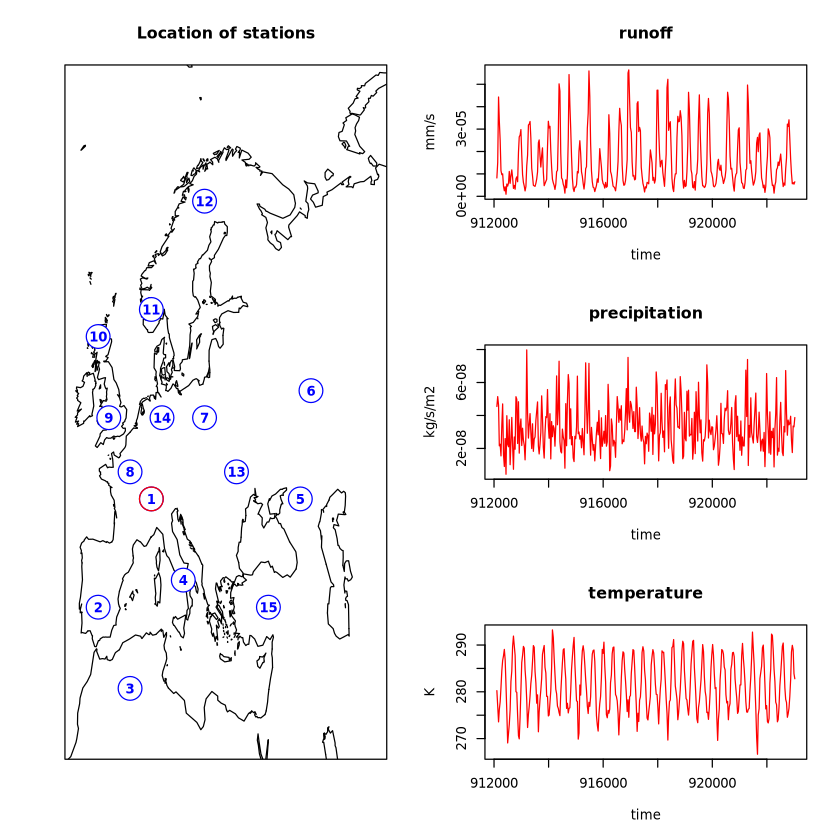

In [5]:
## Plot some of the data

## setup multi panel plot
ll <- cbind(rep(1,3),2:4)
layout(ll)

plot.new()
plot.window(xlim=c(-10,60),ylim=c(30,75))
map("world",add=TRUE,interior=FALSE)
points(lat~lon,data=runoff.station$latlon,cex=4,pch=21,col="blue",bg="white")
station.number <- gsub("Station.","",runoff.station$latlon$Station.id)
with(runoff.station$latlon,text(lon,lat,labels=station.number,col="blue",font=2))
title(main="Location of stations")
box()

## select one staiton on the map
sel.station <- "Station.1" ## you can choose any other station 
points(lat~lon,data=runoff.station$latlon[sel.station,],pch=1,cex=4,col="red")

## plot time series of runoff, precipitation and temperature
with(runoff.station,plot(time,data[,sel.station],t="l",col="red",main="runoff",
                         ylab=att$dat$units))
with(precip.station,plot(time,data[,sel.station],t="l",col="red",main="precipitation",
                         ylab=att$dat$units))
with(temp.station,plot(time,data[,sel.station],t="l",col="red",main="temperature",
                         ylab=att$dat$units))

Load and plot gridded data.

In [6]:
## load
precip.grid <- readRDS("data_Project1/PRECIP_grid.rds")
temp.grid <- readRDS("data_Project1/TEMP_grid.rds")

## inspect data structure
str(precip.grid) ## you can do the same for the other variables

List of 3
 $ dat  : num [1:29, 1:21, 1:360] 6.29e-10 3.51e-10 5.05e-10 5.57e-10 6.72e-10 ...
 $ coord:List of 3
  ..$ lat : num [1:21(1d)] 31.3 33.2 35.1 36.9 38.8 ...
  ..$ lon : num [1:29(1d)] -10 -7.5 -5 -2.5 0 2.5 5 7.5 10 12.5 ...
  ..$ time: num [1:360(1d)] 912104 912135 912166 912194 912225 ...
 $ att  :List of 4
  ..$ dat :List of 3
  .. ..$ _FillValue   : num -9e+33
  .. ..$ missing_value: num -9e+33
  .. ..$ units        : chr "kg/s/m2"
  ..$ lat :List of 4
  .. ..$ standard_name: chr "latitude"
  .. ..$ long_name    : chr "latitude"
  .. ..$ units        : chr "degrees_north"
  .. ..$ axis         : chr "Y"
  ..$ lon :List of 4
  .. ..$ standard_name: chr "longitude"
  .. ..$ long_name    : chr "longitude"
  .. ..$ units        : chr "degrees_east"
  .. ..$ axis         : chr "X"
  ..$ time:List of 5
  .. ..$ standard_name: chr "time"
  .. ..$ long_name    : chr "time"
  .. ..$ units        : chr "days since 0001-01-01 00:00:00"
  .. ..$ calendar     : chr "365_day"
  .. ..$

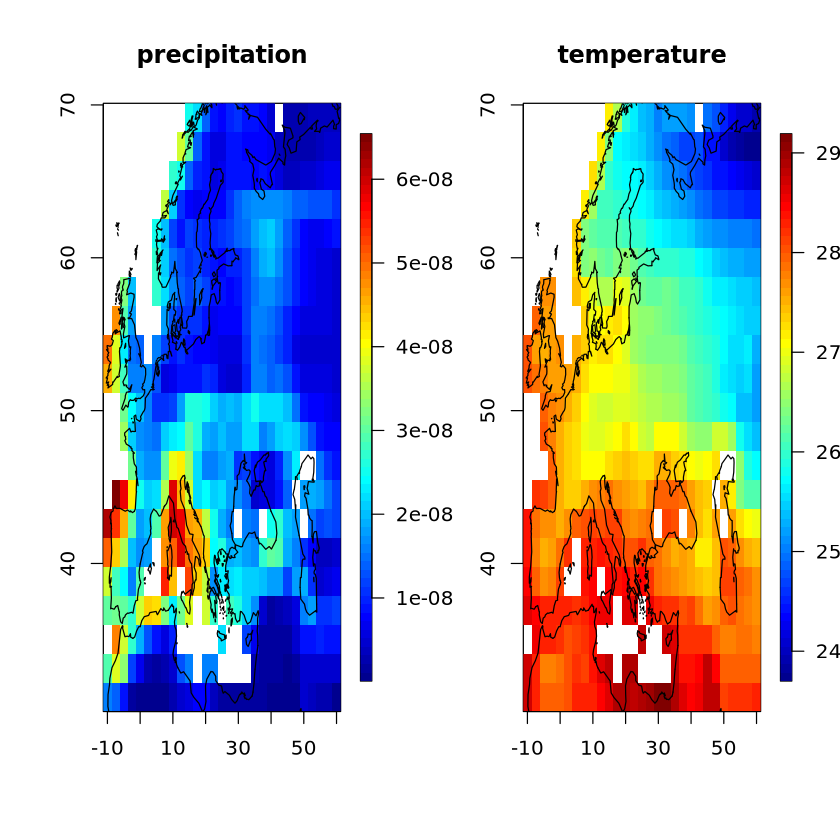

In [7]:
## Plot some of the data

## select a time step (any integer from 1 to 360)
sel.time.step <- 100

par(mfrow=c(1,2))
with(precip.grid,image.plot(x=coord$lon,y=coord$lat,z=dat[,,sel.time.step],
                            main="precipitation",xlab="",ylab=""))
map("world",add=TRUE,interior=FALSE)
##
with(temp.grid,image.plot(x=coord$lon,y=coord$lat,z=dat[,,sel.time.step],
                            main="temperature",xlab="",ylab=""))
map("world",add=TRUE,interior=FALSE)

For estimating runoff as a function of precipitation and temperature
we need to account for present and past information of these variables. 
for doing so, precipitaiton and temperature are embedded into a
time-lagged matrix. Note: for fitting a regression model at more than one location,
the embedded predictors from all locations are stacked on top
of each other in one single table. Trying on artificial data

In [8]:
embed.predictors <- function(x,lambda,var.name){
### function for embedding predictor
###
### x: a vector or a column matrix
### lambda: embedding parameter
### var.name: variable name, used to construct column names of the output
    lambda <- lambda + 1
    if(is.vector(x)){
        x.emb <- embed(x,dimension=lambda)
    } else {    
        x <- t(x)
        xf <- seq(nrow(x))
        x.split <- split(x,f=xf)
        names(x.split) <- rownames(x)
        x.emb <- lapply(x.split,embed,dimension=lambda)
        x.emb <- do.call(rbind,x.emb)
    }
    nms <- paste0(var.name,0:(lambda-1))
    colnames(x.emb) <- nms
    return(x.emb)
}

In [9]:
## artificial data for illustration
embed.predictors(1:10,lambda=2,var.name="x")
embed.predictors(cbind(1:10,11:20),lambda=2,var.name="x")

x0,x1,x2
3,2,1
4,3,2
5,4,3
6,5,4
7,6,5
8,7,6
9,8,7
10,9,8


x0,x1,x2
3,2,1
4,3,2
5,4,3
6,5,4
7,6,5
8,7,6
9,8,7
10,9,8
13,12,11
14,13,12


In [10]:
## application to one single station (try several lambda values!)
precip.one.station.emb <- embed.predictors(precip.station$data[,"Station.1"],lambda=2,var.name="PP")

## inspect
str(precip.one.station.emb)

 num [1:358, 1:3] 4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:3] "PP0" "PP1" "PP2"


In [11]:

## application to one all stations (try several lambda values!)
precip.all.stations.emb <- embed.predictors(precip.station$data,lambda=2,var.name="PP")

## inspect
str(precip.all.stations.emb)

 num [1:5370, 1:3] 4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:3] "PP0" "PP1" "PP2"


Due to the embedding the effective number of time steps that can be used for
modelling is reduced therefore the first lambda time steps need to be discarded. Note: for fitting a regression model at more than one location,
the truncated target time series are stacked on top of
each other in one large table.

In [12]:
truncate.target <- function(x,lambda){
### function for truncating the target variable
###
### x: a vector or a column matrix
### lambda: embedding parameter
    if(is.vector(x)){
        x.trunc <- x[-(1:(lambda))]
    } else {
        x <- t(x)
        xf <- seq(nrow(x))
        x.split <- split(x,f=xf)
        names(x.split) <- rownames(x)
        x.trunc <- lapply(x.split,"[",i=-(1:(lambda)))
        x.trunc <- do.call(c,x.trunc)
    }
    return(x.trunc)
}

In [13]:
## artificial data for illustration
truncate.target(1:10,lambda=2)
truncate.target(cbind(1:10,11:20),lambda=2)

[1]  3  4  5  6  7  8  9 10

[1]  3  4  5  6  7  8  9 10 13 14 15 16 17 18 19 20

In [14]:
## application to one single station
runoff.one.station.trunc <- truncate.target(runoff.station$data[,"Station.1"],lambda=2)

## inspect
str(runoff.one.station.trunc)

 num [1:358] 4.43e-05 3.36e-05 2.49e-05 1.14e-05 9.67e-06 ...


In [15]:
## application to one all stations 
runoff.all.stations.trunc <- truncate.target(runoff.station$data,lambda=2)

## inspect
str(runoff.all.stations.trunc)

 Named num [1:5370] 4.43e-05 3.36e-05 2.49e-05 1.14e-05 9.67e-06 ...
 - attr(*, "names")= chr [1:5370] "Station.11" "Station.12" "Station.13" "Station.14" ...


## Apply Model P1: Prediction of runoff accross Europe

Example work-flow with linear regression to get you started

In [16]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 1 -- Embed the predictor time series and combine data into one table
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## select lambda
sel.lambda <- 2 ## this is likely not an optimal value!

## prepare data from all stations
## 1. embed precipitation and temperature
## 2. truncate runoff
all.stations.for.model.training <- data.frame(
    QQ=truncate.target(runoff.station$data,lambda=sel.lambda),
    embed.predictors(precip.station$data,lambda=sel.lambda,var.name="PP"),
    embed.predictors(temp.station$data,lambda=sel.lambda,var.name="TT")
)

## inspect
str(all.stations.for.model.training)

'data.frame':	5370 obs. of  7 variables:
 $ QQ : num  4.43e-05 3.36e-05 2.49e-05 1.14e-05 9.67e-06 ...
 $ PP0: num  4.62e-08 2.16e-08 2.25e-08 1.55e-08 3.42e-08 ...
 $ PP1: num  5.14e-08 4.62e-08 2.16e-08 2.25e-08 1.55e-08 ...
 $ PP2: num  4.55e-08 5.14e-08 4.62e-08 2.16e-08 2.25e-08 ...
 $ TT0: num  274 276 278 281 285 ...
 $ TT1: num  277 274 276 278 281 ...
 $ TT2: num  280 277 274 276 278 ...


In [17]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 2 -- fit a simple linear regression model
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## Note:
##
## The notation 'QQ~.,data=...' used below indicates that the
## variable named 'QQ' (runoff) should be modelled as a function
## of all other variables in the data.frame 'data' (i.e. embedded precipitation
## and temperature).
##
## many (but not all) regression tools in R support this 'formula'
## notation. 

all.stations.lm <- lm(QQ~.,data=all.stations.for.model.training)

In [18]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 3 -- Predict all stations
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## Note:
##
## for prediction the function 'predict(object=fitted.model,newdata=some.new.data)'
## is used. This workflow is supported by many, but not all, regression
## models in R. The data.frame 'some.new.data' needs to contain
## columns that have the same names as those variables in the data.frame that
## was used for model training (except the target variable)

## create place holder for predictions
all.station.runoff.pred <- runoff.station$data
all.station.runoff.pred[] <- NA

## iterate over stations
for(st in colnames(precip.station$data)){
    ## prepare predictor matrix
    emb.predictors <- data.frame(
        embed.predictors(precip.station$data[,st],lambda=sel.lambda,var.name="PP"),
        embed.predictors(temp.station$data[,st],lambda=sel.lambda,var.name="TT")
    )
    ## do the prediction
    ## Note: the first (sel.lambda) values are left blank as a result of the embedding 
    all.station.runoff.pred[-(1:sel.lambda),st] <- predict(all.stations.lm,newdata=emb.predictors)
}

In [19]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 4 -- Evaluate the performance at the stations
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

##
## overall performance
##

## romean squared error
mean((runoff.station$data - all.station.runoff.pred)^2,na.rm=TRUE)

## R-squared
cor(as.numeric(runoff.station$data),as.numeric(all.station.runoff.pred),use="complete.obs")^2

##
## performance at individual staitions
##

## mean squared error
sapply(colnames(runoff.station$data),function(i){
    mean((runoff.station$data[,i] - all.station.runoff.pred[,i])^2,na.rm=TRUE)
})

## R-squared
sapply(colnames(runoff.station$data),function(i){
    R2 <- cor(as.numeric(runoff.station$data[,i]),as.numeric(all.station.runoff.pred[,i]),
              use="complete.obs")^2
})

[1] 7.459601e-11

[1] 0.5800946

Station.1    Station.2    Station.3    Station.4    Station.5    Station.6 
7.197610e-11 5.431880e-11 5.300090e-11 4.431849e-11 2.453358e-11 4.456931e-11 
   Station.7    Station.8    Station.9   Station.10   Station.11   Station.12 
1.273821e-11 5.045733e-11 5.424340e-11 1.886468e-10 2.767658e-10 1.268098e-10 
  Station.13   Station.14   Station.15 
4.338538e-11 1.166740e-11 6.150891e-11

Station.1  Station.2  Station.3  Station.4  Station.5  Station.6  Station.7 
0.60631833 0.45113720 0.21977749 0.45644940 0.29097703 0.06815675 0.24956338 
 Station.8  Station.9 Station.10 Station.11 Station.12 Station.13 Station.14 
0.49897769 0.43501194 0.73115326 0.67635295 0.20238763 0.41534279 0.37273605 
Station.15 
0.55697172

In [20]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 5 -- Apply the final model to the full grid
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## place holder for predicitons
runoff.grid.pred <- precip.grid$dat
runoff.grid.pred[] <- NA

for(ii in 1:dim(precip.grid$dat)[1]){
    for(jj in 1:dim(precip.grid$dat)[2]){
        emb.predictors <- data.frame(
            embed.predictors(precip.grid$dat[ii,jj,],lambda=sel.lambda,var.name="PP"),
            embed.predictors(temp.grid$dat[ii,jj,],lambda=sel.lambda,var.name="TT")
        )
        ## do the prediction
        ## Note: the first (sel.lambda) values are left blank as a result of the embedding         
        runoff.grid.pred[ii,jj,-(1:sel.lambda)] <- predict(all.stations.lm,newdata=emb.predictors)
    }
}

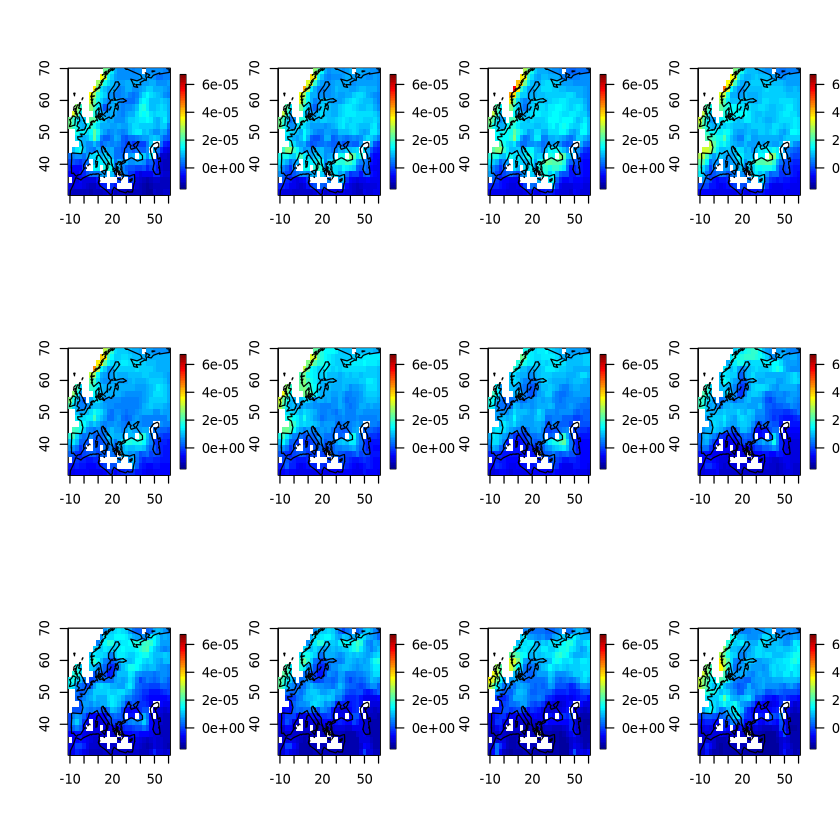

In [21]:
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
## -- 6 -- Inspect and save the data...
##~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## plot some time slices (over 12 months)
runoff.range <- range(runoff.grid.pred,na.rm=TRUE)
par(mfrow=c(3,4))
for(i in 13:24){
    with(precip.grid,image.plot(x=coord$lon,y=coord$lat,
                                z=runoff.grid.pred[,,i],zlim=runoff.range,ann=FALSE))   
    map("world",add=TRUE,interior=FALSE)
}

## save the data (use this as a template for saving the data for submission)
## use following convention for the file name:
## "runoff_*method*_group_*X*.rds"
## --> replace *method* with an acronym of the method/name of the funciton
## used for model training. 
## --> replace *X* with your group number
saveRDS(runoff.grid.pred,file="runoff_lm_group_X.rds")

## Now it's your turn!

In [22]:
# start coding here ...
getwd()
save(temp.grid, file = "temp.grid.RData")


[1] "/home/sc.uni-leipzig.de/bg77ajuc/r-DADA/group_project1"